In [36]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
gpt_data_paths = {
    'kaggle': '/Users/hadleydixon/Desktop/gamification_data_analysis/Data/kaggle_results/all_processed_kaggle.json',
    'aicrowd': '/Users/hadleydixon/Desktop/gamification_data_analysis/Data/aicrowd_results/all_processed_aicrowd.json',
    'drivendata': '/Users/hadleydixon/Desktop/gamification_data_analysis/Data/drivendata_results/all_processed_drivendata.json'
}

In [4]:
processed_gpt_results = {}
for platform, path in gpt_data_paths.items():
    try:
        with open(path, 'r', encoding='utf-8') as f:
            processed_gpt_results[platform] = json.load(f)
        print(f"Loaded {len(processed_gpt_results[platform])} processed results from {platform}")
    except FileNotFoundError:
        print(f"Warning: {path} not found")
    except json.JSONDecodeError:
        print(f"Warning: Error parsing JSON from {path}")

Loaded 300 processed results from kaggle
Loaded 221 processed results from aicrowd
Loaded 66 processed results from drivendata


In [5]:
processed_gpt_dfs = {}
for platform, data in processed_gpt_results.items():
    if data:
        processed_gpt_dfs[platform] = pd.DataFrame(data)
        print(f"Created DataFrame for {platform} with {len(processed_gpt_dfs[platform])} rows")

Created DataFrame for kaggle with 300 rows
Created DataFrame for aicrowd with 221 rows
Created DataFrame for drivendata with 66 rows


In [6]:
kaggle_df = processed_gpt_dfs["kaggle"]
aicrowd_df = processed_gpt_dfs["aicrowd"]
drivendata_df = processed_gpt_dfs["drivendata"]

## Bias & Fairness

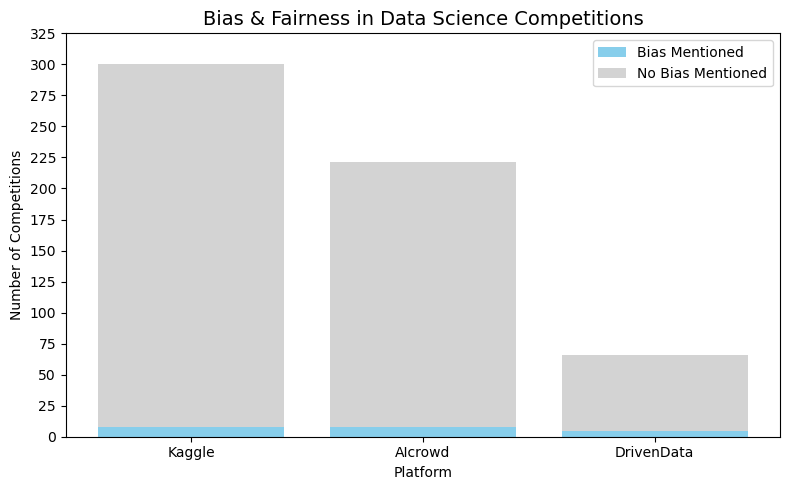

In [7]:
bias_summary_data = []
for platform_name, df in [
    ("Kaggle", kaggle_df),
    ("AIcrowd", aicrowd_df),
    ("DrivenData", drivendata_df)
]:
    total = len(df)
    bias_count = (df['fairness_bias_mentioned'] == "yes").sum()
    non_bias_count = total - bias_count
    bias_summary_data.append({
        "Platform": platform_name,
        "Bias Mentioned": bias_count,
        "No Bias Mentioned": non_bias_count
    })

bias_summary_df = pd.DataFrame(bias_summary_data)

plt.figure(figsize=(8, 5))

plt.bar(bias_summary_df["Platform"], bias_summary_df["Bias Mentioned"], label="Bias Mentioned", color="skyblue")

plt.bar(bias_summary_df["Platform"], bias_summary_df["No Bias Mentioned"],
        bottom=bias_summary_df["Bias Mentioned"], label="No Bias Mentioned", color="lightgray")

plt.title("Bias & Fairness in Data Science Competitions", fontsize=14)
plt.ylabel("Number of Competitions")
plt.xlabel("Platform")
plt.legend()

max_y = bias_summary_df["Bias Mentioned"].add(bias_summary_df["No Bias Mentioned"]).max()
plt.yticks(np.arange(0, max_y + 26, 25))

plt.tight_layout()
plt.show()


In [8]:
bias_summary_df

,Platform,Bias Mentioned,No Bias Mentioned
0,Kaggle,8,292
1,AIcrowd,8,213
2,DrivenData,5,61


In [9]:
total_competitions = 21+566
total_competitions

587

In [10]:
bias_summary_df["No Bias Mentioned"].sum()

np.int64(566)

In [11]:
bias_summary_df["Bias Mentioned"].sum()

np.int64(21)

In [12]:
21/total_competitions

0.03577512776831346

## Data Privacy

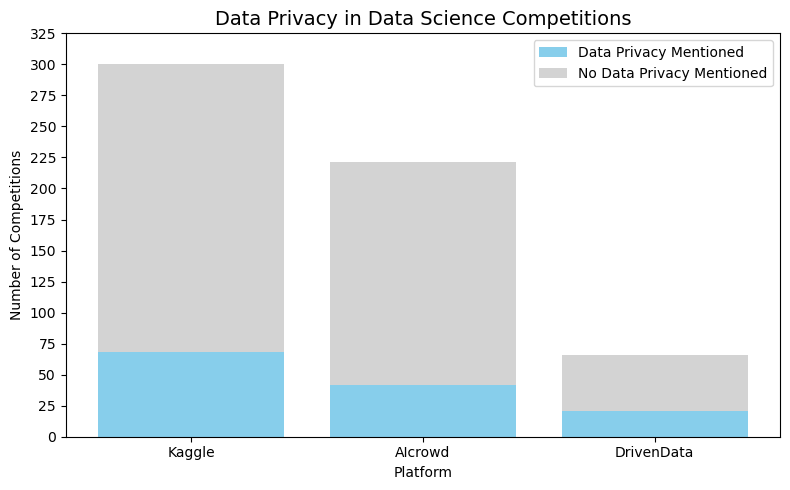

In [13]:
privacy_summary_data = []
for platform_name, df in [
    ("Kaggle", kaggle_df),
    ("AIcrowd", aicrowd_df),
    ("DrivenData", drivendata_df)
]:
    total = len(df)
    privacy_count = (df['data_privacy'] == "yes").sum()
    non_privacy_count = total - privacy_count
    privacy_summary_data.append({
        "Platform": platform_name,
        "Data Privacy Mentioned": privacy_count,
        "No Data Privacy Mentioned": non_privacy_count
    })

privacy_summary_df = pd.DataFrame(privacy_summary_data)

plt.figure(figsize=(8, 5))

plt.bar(privacy_summary_df["Platform"], privacy_summary_df["Data Privacy Mentioned"], label="Data Privacy Mentioned", color="skyblue")

plt.bar(privacy_summary_df["Platform"], privacy_summary_df["No Data Privacy Mentioned"],
        bottom=privacy_summary_df["Data Privacy Mentioned"], label="No Data Privacy Mentioned", color="lightgray")

plt.title("Data Privacy in Data Science Competitions", fontsize=14)
plt.ylabel("Number of Competitions")
plt.xlabel("Platform")
plt.legend()

max_y = privacy_summary_df["Data Privacy Mentioned"].add(privacy_summary_df["No Data Privacy Mentioned"]).max()
plt.yticks(np.arange(0, max_y + 26, 25))

plt.tight_layout()
plt.show()


In [14]:
privacy_summary_df

,Platform,Data Privacy Mentioned,No Data Privacy Mentioned
0,Kaggle,68,232
1,AIcrowd,42,179
2,DrivenData,21,45


In [15]:
privacy_summary_df["Data Privacy Mentioned"].sum()

np.int64(131)

In [16]:
privacy_summary_df["No Data Privacy Mentioned"].sum()

np.int64(456)

In [17]:
131/total_competitions

0.2231686541737649

## Transparency

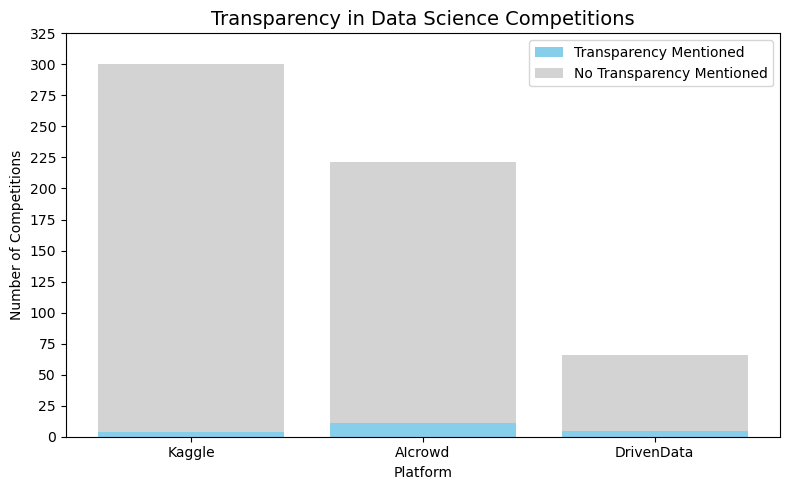

In [18]:
transparency_summary_data = []
for platform_name, df in [
    ("Kaggle", kaggle_df),
    ("AIcrowd", aicrowd_df),
    ("DrivenData", drivendata_df)
]:
    total = len(df)
    transparency_count = (df['transparency_mentioned'] == "yes").sum()
    non_transparency_count = total - transparency_count
    transparency_summary_data.append({
        "Platform": platform_name,
        "Transparency Mentioned": transparency_count,
        "No Transparency Mentioned": non_transparency_count
    })

transparency_summary_df = pd.DataFrame(transparency_summary_data)

plt.figure(figsize=(8, 5))

plt.bar(transparency_summary_df["Platform"], transparency_summary_df["Transparency Mentioned"], label="Transparency Mentioned", color="skyblue")

plt.bar(transparency_summary_df["Platform"], transparency_summary_df["No Transparency Mentioned"],
        bottom=transparency_summary_df["Transparency Mentioned"], label="No Transparency Mentioned", color="lightgray")

plt.title("Transparency in Data Science Competitions", fontsize=14)
plt.ylabel("Number of Competitions")
plt.xlabel("Platform")
plt.legend()

max_y = transparency_summary_df["Transparency Mentioned"].add(transparency_summary_df["No Transparency Mentioned"]).max()
plt.yticks(np.arange(0, max_y + 26, 25))

plt.tight_layout()
plt.show()


In [19]:
transparency_summary_df

,Platform,Transparency Mentioned,No Transparency Mentioned
0,Kaggle,4,296
1,AIcrowd,11,210
2,DrivenData,5,61


In [20]:
transparency_summary_df["Transparency Mentioned"].sum()

np.int64(20)

In [21]:
20/total_competitions

0.034071550255536626

## Toy

In [22]:
total_toy = (
    (kaggle_df["toy"] == "yes").sum()
    + (aicrowd_df["toy"] == "yes").sum()
    + (drivendata_df["toy"] == "yes").sum()
)

print("Total number of toy competitions:", total_toy)

Total number of toy competitions: 202


In [23]:
202/total_competitions

0.3441226575809199

## Red Teaming

In [24]:
total_red = (
    (kaggle_df["red_team"] == "yes").sum()
    + (aicrowd_df["red_team"] == "yes").sum()
    + (drivendata_df["red_team"] == "yes").sum()
)

print("Total number of red teaming competitions:", total_red)

Total number of red teaming competitions: 7


In [25]:
7/total_competitions

0.01192504258943782

#### Revisit URLS for Literature Review

In [26]:
red_urls = pd.concat([
    kaggle_df.loc[kaggle_df["red_team"] == "yes", "url"],
    aicrowd_df.loc[aicrowd_df["red_team"] == "yes", "url"],
    drivendata_df.loc[drivendata_df["red_team"] == "yes", "url"]
], ignore_index=True)

print("\nList of red teaming competition URLs:")
for url in red_urls:
    print(url)


List of red teaming competition URLs:
https://www.kaggle.com/competitions/nips-2017-non-targeted-adversarial-attack
https://www.kaggle.com/competitions/nips-2017-targeted-adversarial-attack
https://www.kaggle.com/competitions/nips-2017-defense-against-adversarial-attack
https://www.kaggle.com/competitions/dogs-vs-cats
https://www.aicrowd.com/challenges/hackaprompt-2023
https://www.drivendata.org/competitions/group/uk-federated-learning/
https://www.drivendata.org/competitions/group/nist-federated-learning/


In [27]:
def yes_mask(s):
    return s.astype(str).str.strip().str.lower().eq("yes")

## Red Teaming: Bias & Fairness

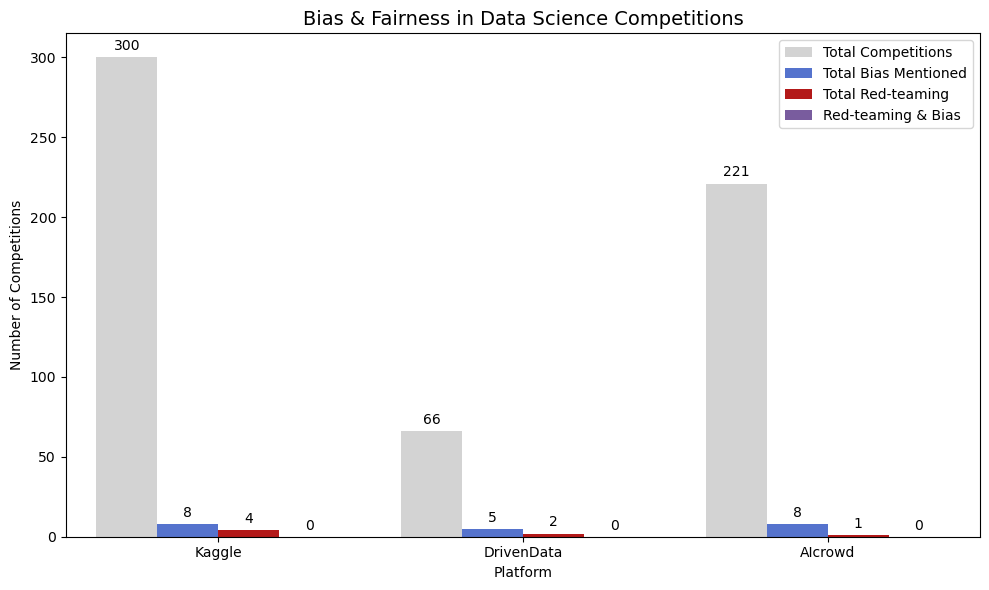

In [28]:
def platform_summary(name, df):
    total = len(df)
    red = yes_mask(df["red_team"]).sum()
    bias = yes_mask(df["fairness_bias_mentioned"]).sum()
    red_and_bias = (yes_mask(df["red_team"]) & yes_mask(df["fairness_bias_mentioned"])).sum()
    return [
        {"Platform": name, "Metric": "Total Competitions", "Count": total},
        {"Platform": name, "Metric": "Total Bias Mentioned", "Count": bias},
        {"Platform": name, "Metric": "Total Red-teaming", "Count": red},
        {"Platform": name, "Metric": "Red-teaming & Bias", "Count": red_and_bias},
    ]

rows = []
rows += platform_summary("Kaggle", kaggle_df)
rows += platform_summary("DrivenData", drivendata_df)
rows += platform_summary("AIcrowd", aicrowd_df)
summary_df = pd.DataFrame(rows)

platform_order = ["Kaggle", "DrivenData", "AIcrowd"]
metric_order = ["Total Competitions", "Total Bias Mentioned", "Total Red-teaming", "Red-teaming & Bias"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_df,
    x="Platform", y="Count", hue="Metric",
    order=platform_order, hue_order=metric_order,
    palette=["#d3d3d3", "#4169e1", "#cc0000", "#7851a9"]
)

ax.set_title("Bias & Fairness in Data Science Competitions", fontsize=14)
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Competitions")
ax.legend(frameon=True)

for container in ax.containers:
    labels = [f"{int(v)}" for v in container.datavalues] 
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()


## Red Teaming: Data Privacy

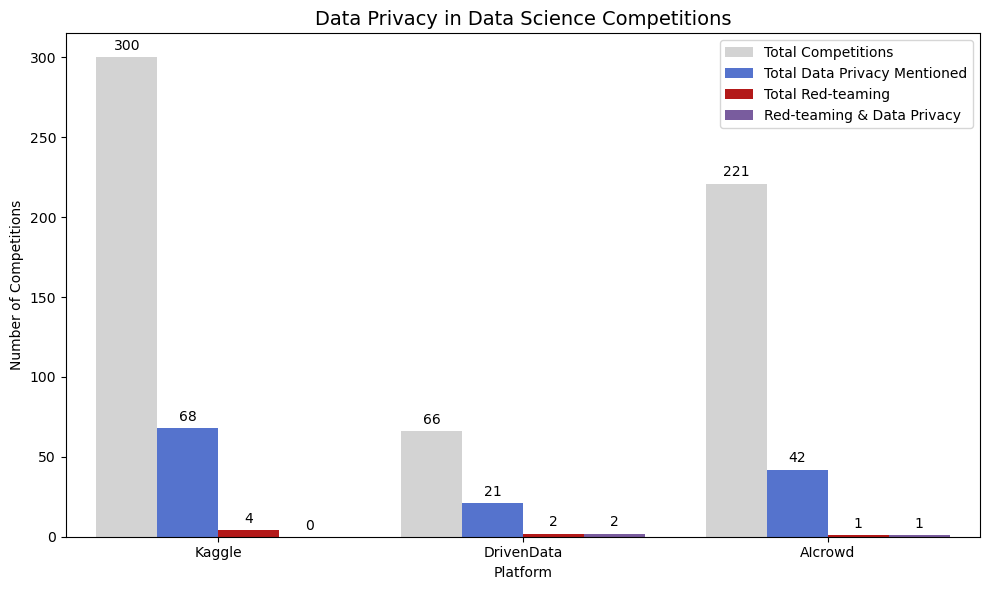

In [29]:
def platform_summary(name, df):
    total = len(df)
    red = yes_mask(df["red_team"]).sum()
    privacy = yes_mask(df["data_privacy"]).sum()
    red_and_privacy = (yes_mask(df["red_team"]) & yes_mask(df["data_privacy"])).sum()
    return [
        {"Platform": name, "Metric": "Total Competitions", "Count": total},
        {"Platform": name, "Metric": "Total Data Privacy Mentioned", "Count": privacy},
        {"Platform": name, "Metric": "Total Red-teaming", "Count": red},
        {"Platform": name, "Metric": "Red-teaming & Data Privacy", "Count": red_and_privacy},
    ]

rows = []
rows += platform_summary("Kaggle", kaggle_df)
rows += platform_summary("DrivenData", drivendata_df)
rows += platform_summary("AIcrowd", aicrowd_df)
summary_df = pd.DataFrame(rows)

platform_order = ["Kaggle", "DrivenData", "AIcrowd"]
metric_order = ["Total Competitions", "Total Data Privacy Mentioned", "Total Red-teaming", "Red-teaming & Data Privacy"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_df,
    x="Platform", y="Count", hue="Metric",
    order=platform_order, hue_order=metric_order,
    palette=["#d3d3d3", "#4169e1", "#cc0000", "#7851a9"]
)

ax.set_title("Data Privacy in Data Science Competitions", fontsize=14)
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Competitions")
ax.legend(frameon=True)

for container in ax.containers:
    labels = [f"{int(v)}" for v in container.datavalues] 
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()


## Red Teaming: Transparency

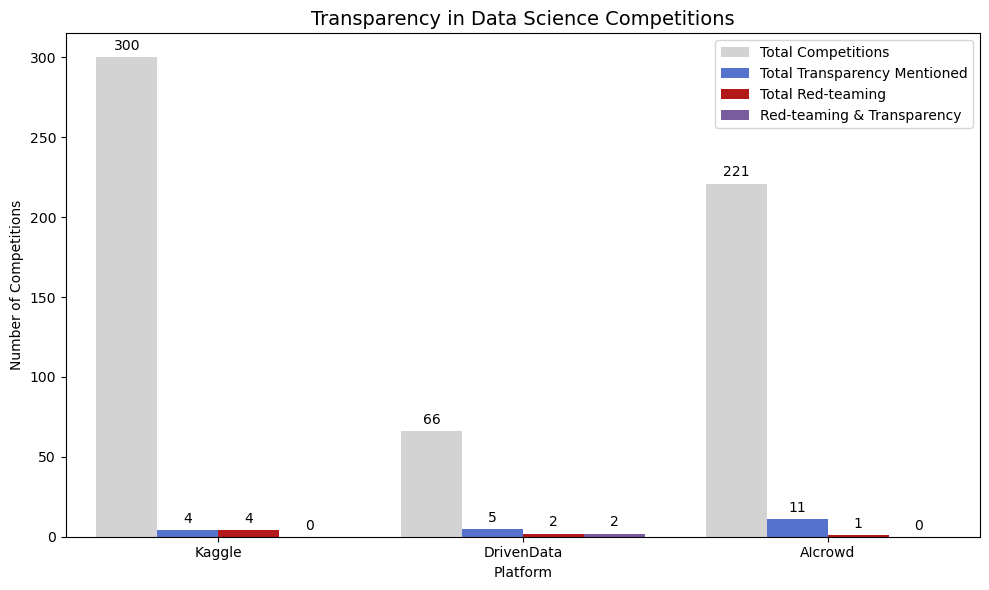

In [30]:
def platform_summary(name, df):
    total = len(df)
    red = yes_mask(df["red_team"]).sum()
    transparency = yes_mask(df["transparency_mentioned"]).sum()
    red_and_transparency = (yes_mask(df["red_team"]) & yes_mask(df["transparency_mentioned"])).sum()
    return [
        {"Platform": name, "Metric": "Total Competitions", "Count": total},
        {"Platform": name, "Metric": "Total Transparency Mentioned", "Count": transparency},
        {"Platform": name, "Metric": "Total Red-teaming", "Count": red},
        {"Platform": name, "Metric": "Red-teaming & Transparency", "Count": red_and_transparency},
    ]

rows = []
rows += platform_summary("Kaggle", kaggle_df)
rows += platform_summary("DrivenData", drivendata_df)
rows += platform_summary("AIcrowd", aicrowd_df)
summary_df = pd.DataFrame(rows)

platform_order = ["Kaggle", "DrivenData", "AIcrowd"]
metric_order = ["Total Competitions", "Total Transparency Mentioned", "Total Red-teaming", "Red-teaming & Transparency"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_df,
    x="Platform", y="Count", hue="Metric",
    order=platform_order, hue_order=metric_order,
    palette=["#d3d3d3", "#4169e1", "#cc0000", "#7851a9"]
)

ax.set_title("Transparency in Data Science Competitions", fontsize=14)
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Competitions")
ax.legend(frameon=True)

for container in ax.containers:
    labels = [f"{int(v)}" for v in container.datavalues] 
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()


## Red Teaming: Toy

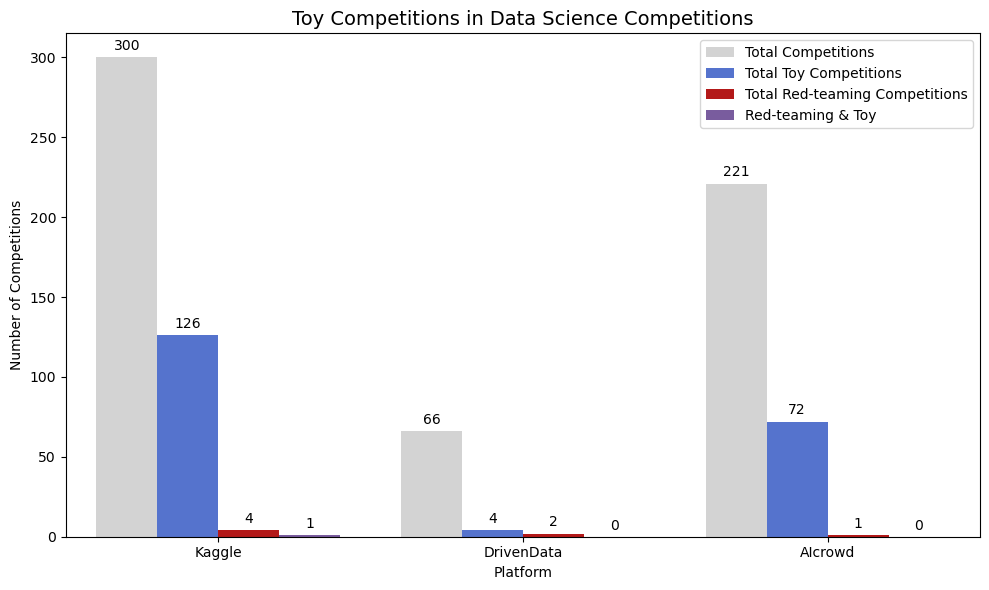

In [31]:
def platform_summary(name, df, masked_column):
    total = len(df)
    red = yes_mask(df["red_team"]).sum()
    masked = yes_mask(df[masked_column]).sum()
    red_and_masked = (yes_mask(df["red_team"]) & yes_mask(df[masked_column])).sum()
    return [
        {"Platform": name, "Metric": "Total Competitions", "Count": total},
        {"Platform": name, "Metric": "Total Toy Competitions", "Count": masked},
        {"Platform": name, "Metric": "Total Red-teaming Competitions", "Count": red},
        {"Platform": name, "Metric": "Red-teaming & Toy", "Count": red_and_masked},
    ]

rows = []
rows += platform_summary("Kaggle", kaggle_df, "toy")
rows += platform_summary("DrivenData", drivendata_df, "toy")
rows += platform_summary("AIcrowd", aicrowd_df, "toy")
summary_df = pd.DataFrame(rows)

platform_order = ["Kaggle", "DrivenData", "AIcrowd"]
metric_order = ["Total Competitions", "Total Toy Competitions", "Total Red-teaming Competitions", "Red-teaming & Toy"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_df,
    x="Platform", y="Count", hue="Metric",
    order=platform_order, hue_order=metric_order,
    palette=["#d3d3d3", "#4169e1", "#cc0000", "#7851a9"]
)

ax.set_title("Toy Competitions in Data Science Competitions", fontsize=14)
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Competitions")
ax.legend(frameon=True)

for container in ax.containers:
    labels = [f"{int(v)}" for v in container.datavalues] 
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()


# Overall

In [40]:
full_summary_df = pd.DataFrame({
    "platform": ["Kaggle", "DrivenData", "AIcrowd", "All"],
    "total": [300, 66, 221, 587],
    "red_team": [4,2,1,7],
    "bias": [8, 5, 8, 21],
    "red_team_bias": [0, 0, 0, 0],
    "privacy": [68, 66, 42, 131],
    "red_team_privacy": [0, 2, 1, 3],
    "transparency": [4, 5, 11, 20],
    "red_team_transparency": [0, 2, 0, 2],
    "toy": [126, 4, 72, 202],
    "red_team_toy": [1, 0, 0, 1],
})

full_summary_df

,platform,total,red_team,bias,red_team_bias,privacy,red_team_privacy,transparency,red_team_transparency,toy,red_team_toy
0,Kaggle,300,4,8,0,68,0,4,0,126,1
1,DrivenData,66,2,5,0,66,2,5,2,4,0
2,AIcrowd,221,1,8,0,42,1,11,0,72,0
3,All,587,7,21,0,131,3,20,2,202,1


## Save as .csv

In [35]:
red_df = pd.concat([
    kaggle_df.loc[yes_mask(kaggle_df["red_team"])].assign(Platform="Kaggle"),
    aicrowd_df.loc[yes_mask(aicrowd_df["red_team"])].assign(Platform="AIcrowd"),
    drivendata_df.loc[yes_mask(drivendata_df["red_team"])].assign(Platform="DrivenData"),
], ignore_index=True)

print(f"Total red-teaming rows: {len(red_df)}")
red_df

Total red-teaming rows: 7


,category,fairness_bias_mentioned,how_fairness,data_privacy,how_data_privacy,toy,red_team,transparency_mentioned,how_transparency,name,url,Platform
0,Machine Learning and AI Security,no,n/a,no,n/a,no,yes,no,n/a,NIPS 2017: Non-targeted Adversarial Attack,https://www.kaggle.com/competitions/nips-2017-...,Kaggle
1,Machine Learning Security,no,n/a,no,n/a,no,yes,no,n/a,NIPS 2017: Targeted Adversarial Attack,https://www.kaggle.com/competitions/nips-2017-...,Kaggle
2,Machine Learning/Security,no,n/a,no,n/a,no,yes,no,n/a - focuses on adversarial attacks and defenses,NIPS 2017: Defense Against Adversarial Attack,https://www.kaggle.com/competitions/nips-2017-...,Kaggle
3,Computer Vision,no,n/a,no,n/a,yes,yes,no,"n/a, the focus is on classification accuracy",Dogs vs. Cats,https://www.kaggle.com/competitions/dogs-vs-cats,Kaggle
4,AI Safety and Prompt Engineering,no,n/a,yes,There is potential exposure of participants' d...,no,yes,no,n/a; the competition focuses on performance me...,NaN,https://www.aicrowd.com/challenges/hackaprompt...,AIcrowd
5,Privacy-enhancing technologies and federated l...,no,n/a,yes,The competition involves analyzing sensitive d...,no,yes,yes,Competitors must prove or demonstrate the priv...,NaN,https://www.drivendata.org/competitions/group/...,DrivenData
6,Data Privacy and Security,no,n/a,yes,The challenge focuses on developing privacy-pr...,no,yes,yes,Usability and Explainability are part of the e...,NaN,https://www.drivendata.org/competitions/group/...,DrivenData


In [41]:
# Save to the current directory
out = Path(".")

kaggle_df.to_csv(out / "kaggle_competitions.csv", index=True)
drivendata_df.to_csv(out / "drivendata_competitions.csv", index=True)
aicrowd_df.to_csv(out / "aicrowd_competitions.csv", index=True)
red_df.to_csv(out / "red_teaming_competitions.csv", index=True)
full_summary_df.to_csv(out / "summary_stats.csv", index=True)


print("Saved:",
      (out / "kaggle_competitions.csv"),
      (out / "drivendata_competitions.csv"),
      (out / "aicrowd_competitions.csv"),
      (out / "red_teaming_competitions.csv"),
      (out / "summary_stats.csv"),
)

Saved: kaggle_competitions.csv drivendata_competitions.csv aicrowd_competitions.csv red_teaming_competitions.csv summary_stats.csv
